# Titanic Exploratory Data Analysis (EDA)

## Objective

The objective of this project is to perform Exploratory Data Analysis (EDA) on the Titanic dataset to discover meaningful patterns, relationships, and trends using statistical summaries and visualizations.

The insights obtained from this analysis can help understand the factors that influenced passenger survival.

## Step 1: Import Required Libraries

The required Python libraries are imported for data manipulation, statistical analysis, and visualization.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Step 2: Load the Dataset

The Titanic dataset is loaded into a Pandas DataFrame for analysis.

In [2]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Step 3: Dataset Overview

Before analyzing the data, it is important to understand the dataset structure including the number of rows, columns, data types, and missing values.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df.shape

(891, 12)

In [5]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

## Step 4: Statistical Summary

Statistical summaries provide useful information such as count, mean, minimum, maximum, and standard deviation for numerical columns.

In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Step 5: Missing Values Analysis

Checking missing values helps identify incomplete data that may require preprocessing before further analysis.

In [7]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


## Investigation 1: Survival by Gender

This analysis explores whether a passenger's gender influenced their chances of survival.

A count plot is used to compare the number of survivors and non-survivors for males and females.

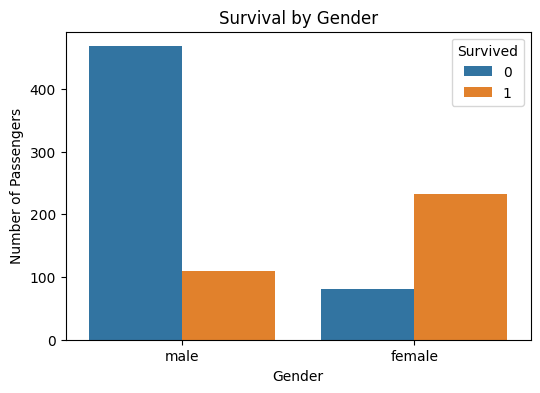

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x="Sex", hue="Survived", data=df)
plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.show()

### Observation

Female passengers had a significantly higher survival rate than male passengers.

This suggests that gender played an important role in determining survival during the Titanic disaster.

## Investigation 2: Survival by Passenger Class

Passenger class may have influenced survival because higher-class passengers had better access to lifeboats.

This visualization compares survival across different passenger classes.

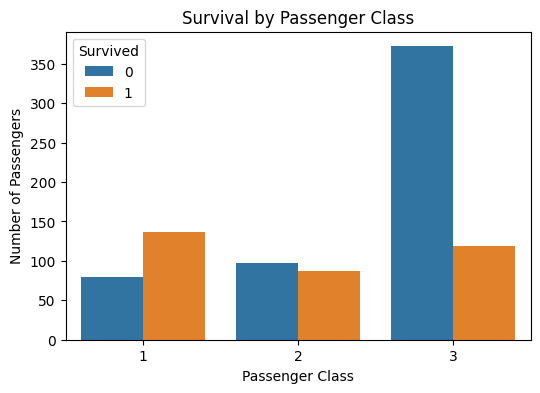

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x="Pclass", hue="Survived", data=df)
plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.show()

### Observation

Passengers traveling in First Class had the highest survival rate, while passengers in Third Class experienced the lowest survival rate.

This indicates that passenger class had a strong influence on survival.

## Investigation 3: Age Distribution

The age distribution of passengers helps understand which age groups were most represented on the Titanic.

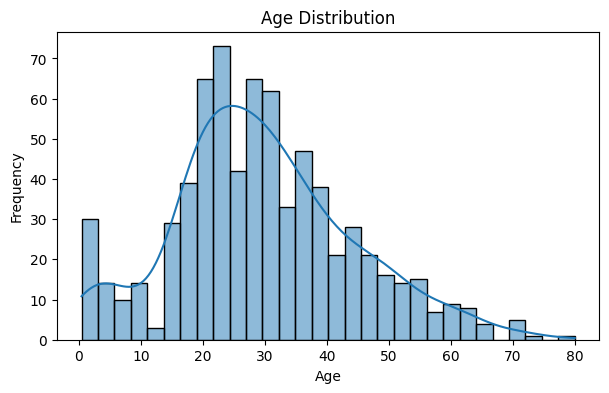

In [10]:
plt.figure(figsize=(7,4))
sns.histplot(df["Age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

### Observation

Most passengers were young adults between approximately 20 and 40 years of age.

The dataset also includes children and elderly passengers, although they were fewer in number.

## Investigation 4: Fare Distribution

This analysis examines how ticket fares were distributed among passengers.

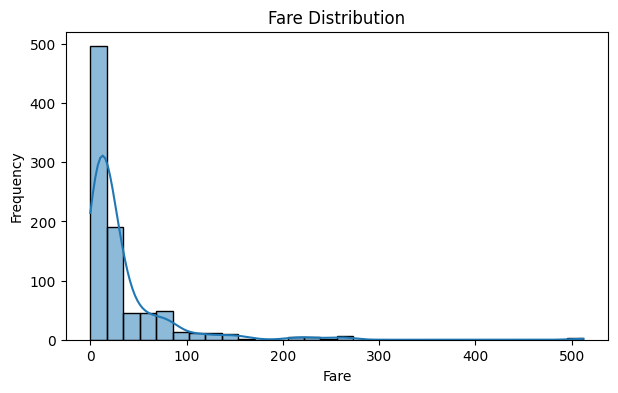

In [11]:
plt.figure(figsize=(7,4))
sns.histplot(df["Fare"], bins=30, kde=True)
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.show()

### Observation

Most passengers paid relatively low ticket fares, while only a small number paid very high fares.

This indicates that the fare distribution is positively skewed.

## Investigation 5: Correlation Analysis

A correlation heatmap is used to understand the relationships between numerical variables in the dataset.

Correlation values range from -1 to +1:
- +1 indicates a strong positive relationship.
- -1 indicates a strong negative relationship.
- 0 indicates little or no relationship.

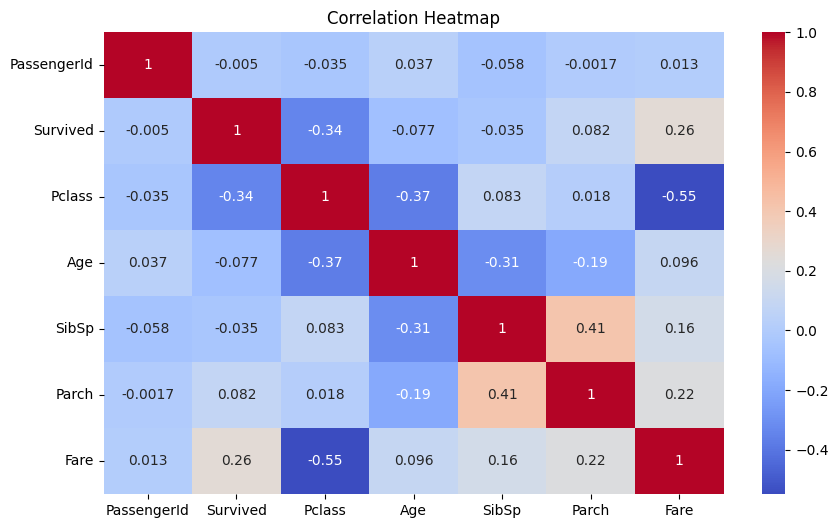

In [12]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### Observation

The heatmap shows the relationships between numerical variables.

Passenger class (Pclass) has a negative correlation with survival, indicating that passengers in higher classes had better chances of survival.

Fare also shows a positive relationship with survival, suggesting that passengers who paid higher fares were more likely to survive.

## Investigation 6: Age Distribution by Survival

A box plot is used to compare the age distribution of passengers who survived and those who did not survive.

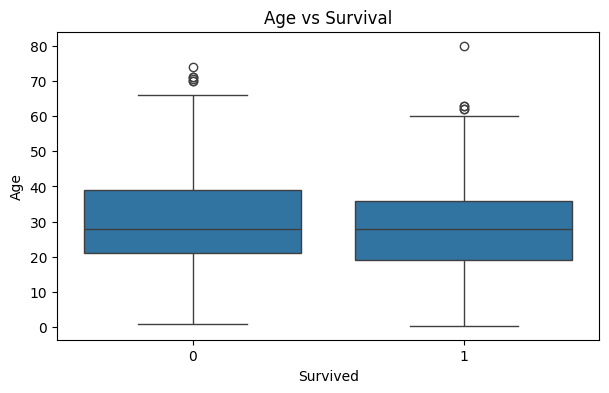

In [13]:
plt.figure(figsize=(7,4))
sns.boxplot(x="Survived", y="Age", data=df)
plt.title("Age vs Survival")
plt.show()

### Observation

The box plot shows the spread of passenger ages for both survivors and non-survivors.

Although passengers of all ages were affected, the age distributions show slight differences between the two groups.

## Investigation 7: Fare Distribution Across Passenger Classes

This analysis examines how ticket fares varied across different passenger classes.

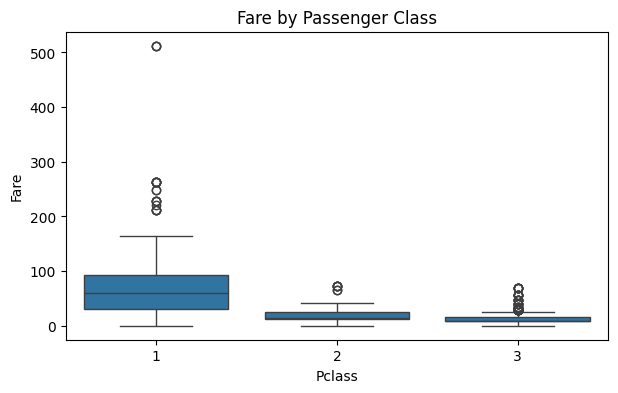

In [14]:
plt.figure(figsize=(7,4))
sns.boxplot(x="Pclass", y="Fare", data=df)
plt.title("Fare by Passenger Class")
plt.show()

### Observation

First Class passengers generally paid much higher fares than Second and Third Class passengers.

The fare distribution also contains several outliers, representing passengers who paid exceptionally high ticket prices.

## Investigation 8: Family Size Analysis

A new feature called FamilySize is created by adding the number of siblings/spouses (SibSp) and parents/children (Parch), along with the passenger.

This helps analyze whether travelling alone or with family influenced survival.

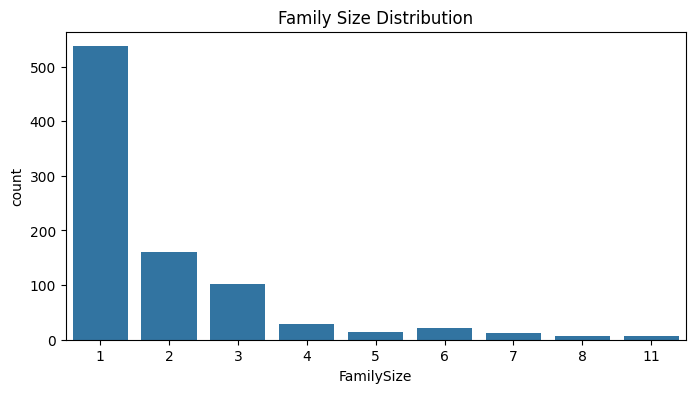

In [15]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
plt.figure(figsize=(8,4))
sns.countplot(x="FamilySize", data=df)
plt.title("Family Size Distribution")
plt.show()

### Observation

Most passengers traveled alone or with a small family.

Very large families were relatively uncommon on the Titanic.

# Conclusion

This Exploratory Data Analysis (EDA) project examined the Titanic dataset to identify factors that influenced passenger survival.

## Key Findings

- Female passengers had significantly higher survival rates than male passengers.
- First Class passengers had better chances of survival than Third Class passengers.
- Most passengers were between 20 and 40 years of age.
- Ticket fares varied greatly, with First Class passengers paying the highest fares.
- Small family groups were more common than large families.
- Correlation analysis showed that passenger class and fare were associated with survival.

## Tools Used

- Python
- Pandas
- Matplotlib
- Seaborn
- Google Colab

This project demonstrates how Exploratory Data Analysis helps uncover patterns and insights from real-world datasets before applying machine learning techniques.